E-Commerce Customer Spending Prediction
The aim of this is to predict the total amount spent by a customer based on their e-commerce shopping behavior.
The target variable is Monetary, which represents the customers total spending.

<h2>1.Dataset Loading and Audit</h2>

Important Required Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

<h2>1.1 Dataset Loading</h2>

Using pandas for loading data set 

In [37]:
df = pd.read_csv("ecommerce_user_segmentation.csv")
df.head()

,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns,Segment_Label
0,CUST00001,51,13,1560,113,56,14.766242,33,828,1,28,17.629489,8,Silver
1,CUST00002,134,5,3,26,7,5.409044,2,60,0,4,23.024216,9,Iron
2,CUST00003,55,15,235,57,37,5.082231,11,710,1,17,28.391939,16,Copper
3,CUST00004,46,11,1293,191,48,18.936486,20,1223,0,17,15.192267,0,Silver
4,CUST00005,21,30,3602,239,90,26.461395,37,1892,0,57,11.427460,8,Gold


<h2>1.2 Dataset Audit</h2>

Now for the dataset we seeing the size, columns, data types, missing values, duplicate records, and basic statistical properties.

In [38]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nStatistical Summary:")
df.describe()

Shape: (10000, 14)

Columns:
Index(['Customer_ID', 'Recency', 'Frequency', 'Monetary', 'Avg_Order_Value',
       'Session_Count', 'Avg_Session_Duration', 'Pages_Viewed', 'Clicks',
       'Campaign_Response', 'Wishlist_Adds', 'Cart_Abandon_Rate', 'Returns',
       'Segment_Label'],
      dtype='str')

Data Types:
Customer_ID                 str
Recency                   int64
Frequency                 int64
Monetary                  int64
Avg_Order_Value           int64
Session_Count             int64
Avg_Session_Duration    float64
Pages_Viewed              int64
Clicks                    int64
Campaign_Response         int64
Wishlist_Adds             int64
Cart_Abandon_Rate       float64
Returns                   int64
Segment_Label               str
dtype: object

Missing Values:
Customer_ID             0
Recency                 0
Frequency               0
Monetary                0
Avg_Order_Value         0
Session_Count           0
Avg_Session_Duration    0
Pages_Viewed            0

,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,48.665400,28.783000,1938.394600,146.599900,55.915800,15.444645,33.99840,1211.465100,0.416700,28.618300,17.653052,7.268800
std,37.818734,23.133669,2327.840348,87.564246,43.551484,8.133285,21.14206,1058.875362,0.493037,23.544257,10.013803,5.623247
min,1.000000,0.000000,0.000000,10.000000,0.000000,1.000433,1.00000,50.000000,0.000000,0.000000,0.007050,0.000000
25%,22.000000,10.000000,269.000000,79.000000,22.000000,9.515457,18.00000,451.750000,0.000000,11.000000,10.829601,3.000000
50%,40.000000,20.000000,1022.000000,135.000000,44.000000,14.305176,30.00000,871.000000,0.000000,21.000000,15.908491,6.000000
75%,63.000000,40.000000,2825.250000,196.000000,75.000000,19.725305,46.00000,1518.000000,1.000000,41.000000,22.769516,11.000000
max,179.000000,99.000000,9995.000000,399.000000,199.000000,39.995729,99.00000,4998.000000,1.000000,99.000000,49.994254,24.000000


<h2>1.3 Target Variable Identification</h2>

Target Variable 
For this regression we use Monetary as the target variable.
It represents the total amount spent by a customer.

In [39]:
X = df.drop("Monetary", axis=1)
y = df["Monetary"]
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (10000, 13)
Target shape: (10000,)


<h2>2.Exploratory Data Analysis </h2>

These plots help identify skewness, unusual values, and possible outliers in the dataset.

<h2>2.1 Distrubution of Numerical Features</h2>

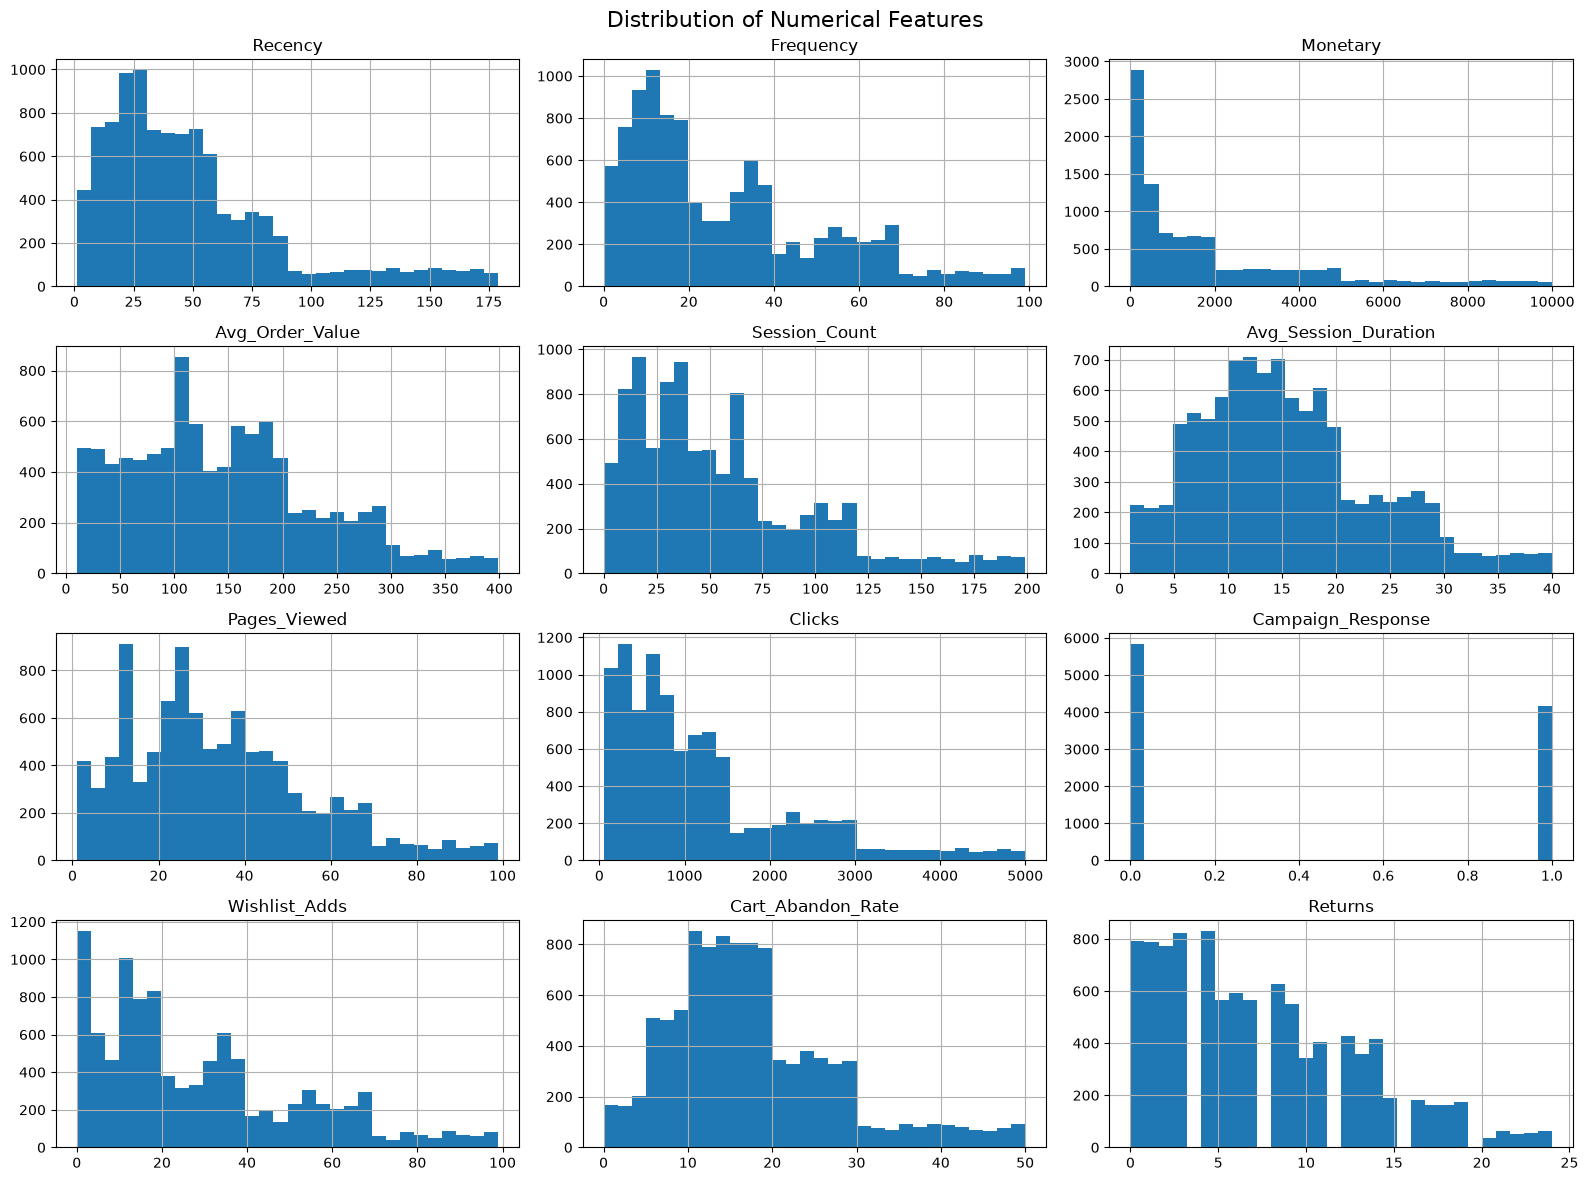

In [40]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].hist(figsize=(16, 12), bins=30)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

The distribution plots show the spread of the numerical variables. Some features have a wider range than others, while some variables show concentration around particular values. The plots also help identify potential skewness and unusual observations that may need to be considered during preprocessing.

<h2>2.2 Target Variable Distribution</h2>

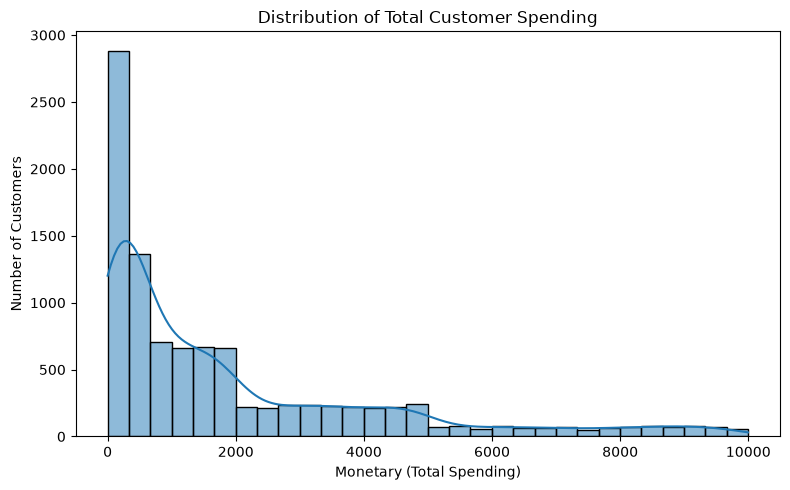

In [41]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Monetary"], bins=30, kde=True)

plt.title("Distribution of Total Customer Spending")
plt.xlabel("Monetary (Total Spending)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

The target distribution shows how total customer spending varies across the customers in the dataset. It helps us understand whether spending is concentrated around a particular range or whether there are customers with substantially higher spending.

<h2>2.3 Correlation Heatmap</h2>

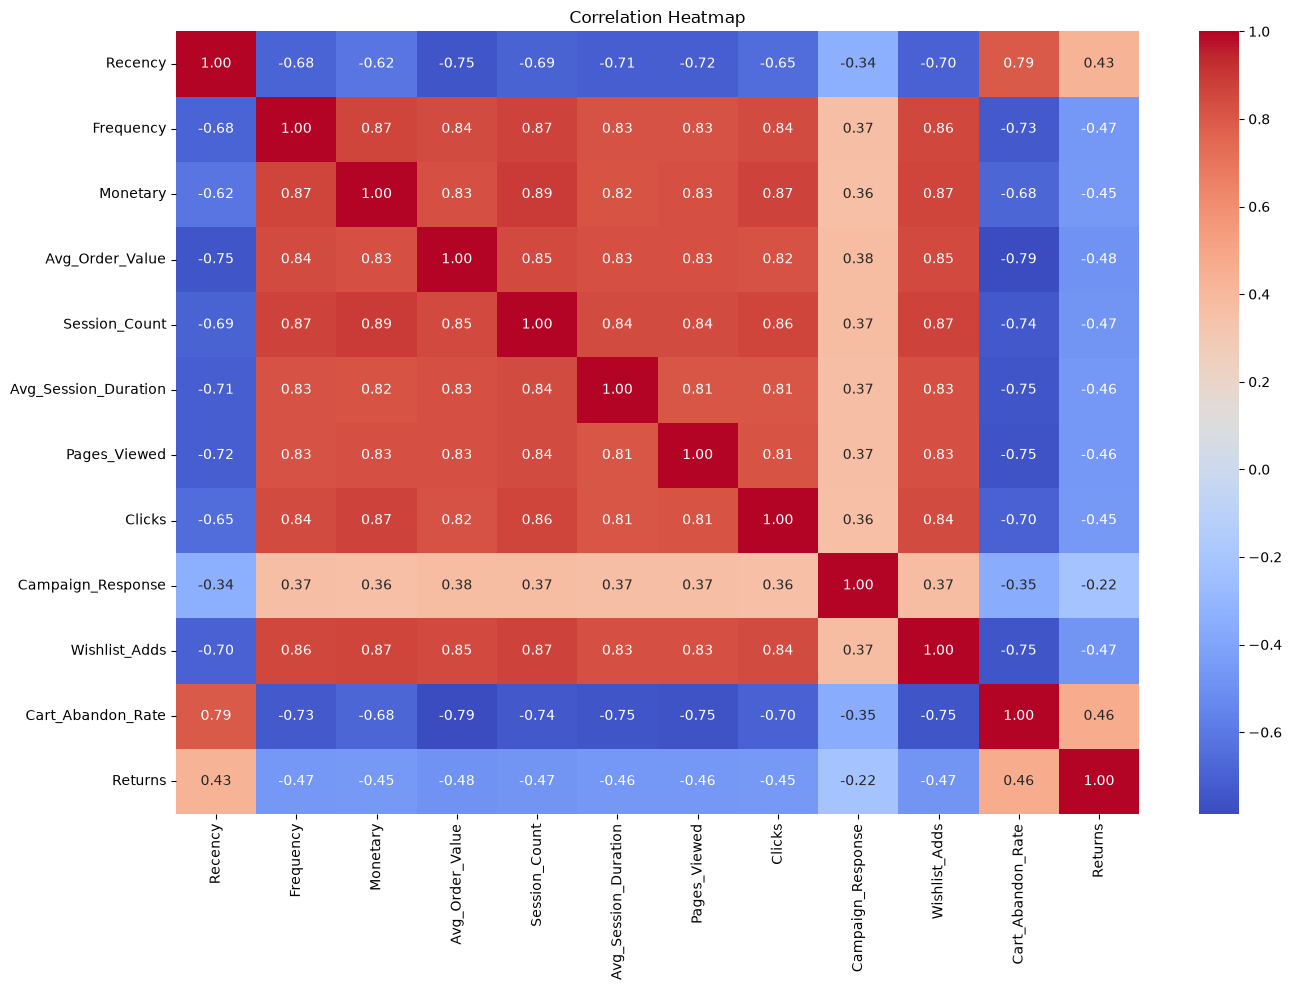

In [42]:
plt.figure(figsize=(14, 10))

correlation = df[numeric_columns].corr()

sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

The correlation heatmap shows the relationships between the numerical variables.

The features showing stronger positive correlation with `Monetary` may provide useful information for predicting customer spending.

Features with weak correlation may still contribute to the regression models when combined with other variables.

<h2>2.4 Feature - Target Relationship :Frequency vs Monetary</h2>

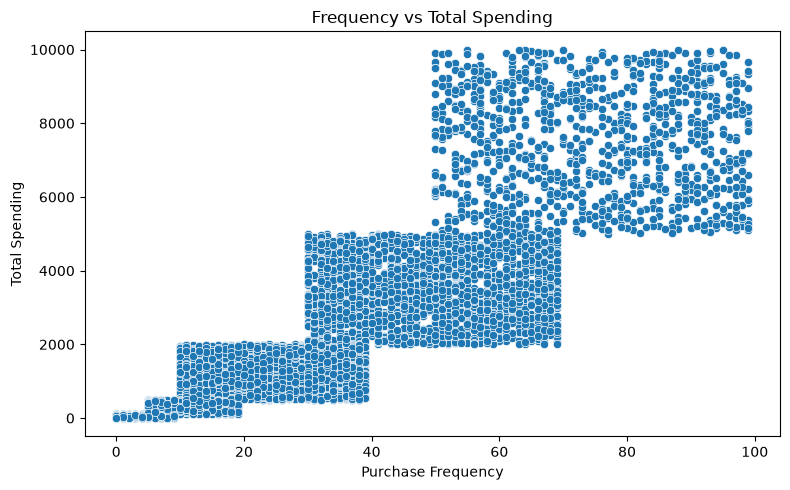

In [43]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Frequency", y="Monetary")

plt.title("Frequency vs Total Spending")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()

The scatter plot shows the relationship between purchase frequency and total customer spending. The pattern indicates whether customers who purchase more frequently tend to have higher total spending.

<h2>2.5 Feature-Target Relationship:Average Order Value vs Monetary</h2>

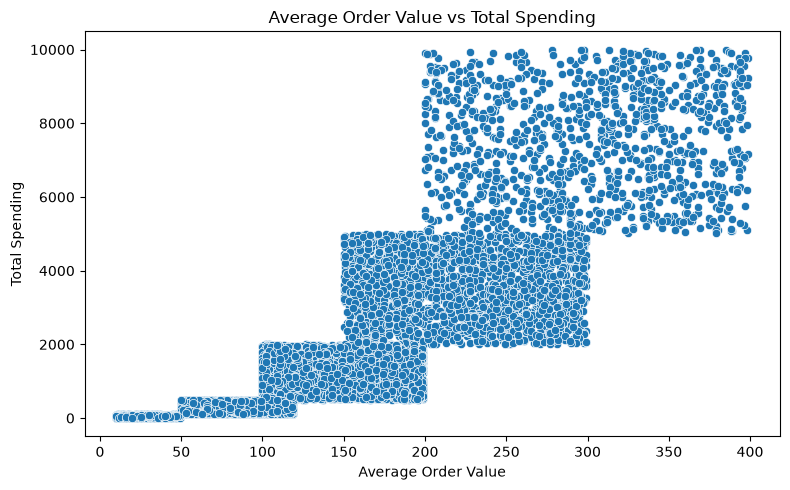

In [44]:
plt.figure(figsize=(8, 5))

sns.scatterplot(data=df, x="Avg_Order_Value", y="Monetary")

plt.title("Average Order Value vs Total Spending")
plt.xlabel("Average Order Value")
plt.ylabel("Total Spending")

plt.tight_layout()
plt.show()

The scatter plot shows the relationship between average order value and total customer spending. This relationship helps us understand whether customers with larger average orders tend to have higher overall spending.

<h2>3.Data Preprocessing  Feature Engineering</h2>

<h2>3.1 Missing Value Handling</h2>

In [45]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Customer_ID             0
Recency                 0
Frequency               0
Monetary                0
Avg_Order_Value         0
Session_Count           0
Avg_Session_Duration    0
Pages_Viewed            0
Clicks                  0
Campaign_Response       0
Wishlist_Adds           0
Cart_Abandon_Rate       0
Returns                 0
Segment_Label           0
dtype: int64


<h2>3.2 Duplicate Record Check and Removing Duplicates</h2>

In [46]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [47]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (10000, 14)


In [48]:
if "Customer_ID" in df.columns:
    df = df.drop("Customer_ID", axis=1)

if "Segment_Label" in df.columns:
    df = df.drop("Segment_Label", axis=1)

print(df.columns)

Index(['Recency', 'Frequency', 'Monetary', 'Avg_Order_Value', 'Session_Count',
       'Avg_Session_Duration', 'Pages_Viewed', 'Clicks', 'Campaign_Response',
       'Wishlist_Adds', 'Cart_Abandon_Rate', 'Returns'],
      dtype='str')


<h2>3.3 Outlier Detection and Handling Outliers </h2>

In [49]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[column] >= lower) & (df[column] <= upper)]

print("Shape after IQR outlier removal:", df.shape)

Shape after IQR outlier removal: (7573, 12)


<h2>4.Feature Engineering</h2>

In [50]:
df["Engagement_Score"] = (
    df["Session_Count"] +
    df["Pages_Viewed"] +
    df["Clicks"] +
    df["Wishlist_Adds"]
)

print(df[[
    "Session_Count",
    "Pages_Viewed",
    "Clicks",
    "Wishlist_Adds",
    "Engagement_Score"
]].head())

   Session_Count  Pages_Viewed  Clicks  Wishlist_Adds  Engagement_Score
0             56            33     828             28               945
2             37            11     710             17               775
3             48            20    1223             17              1308
4             90            37    1892             57              2076
5            114            53    2187             63              2417


An Engagement_Score feature was created by combining session count, pages viewed, clicks, and wishlist additions.

This feature represents the overall level of customer engagement with the e-commerce platform.

<h2>5.Feature and Target Selection</h2>

In [51]:
X = df.drop("Monetary", axis=1)
y = df["Monetary"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (7573, 12)
Target: (7573,)


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)


Training data: (6058, 12)
Testing data: (1515, 12)


In [53]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:", X_train_scaled.shape)
print("Testing data after scaling:", X_test_scaled.shape)

Training data after scaling: (6058, 12)
Testing data after scaling: (1515, 12)


<h2>6.Regrssion Model Implementation</h2>

In [54]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

linear_pred = linear_model.predict(X_test_scaled)

linear_r2 = r2_score(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))
linear_mae = mean_absolute_error(y_test, linear_pred)

print("Linear Regression")
print("R2:", linear_r2)
print("RMSE:", linear_rmse)
print("MAE:", linear_mae)

Linear Regression
R2: 0.7893320736356938
RMSE: 595.750705511454
MAE: 439.5280392535997


In [55]:
# 2.Ridge Regression
ridge_model = Ridge(alpha=1.0)

ridge_model.fit(X_train_scaled, y_train)

ridge_pred = ridge_model.predict(X_test_scaled)


# 3.Lasso Regression
lasso_model = Lasso(alpha=0.1)

lasso_model.fit(X_train_scaled, y_train)

lasso_pred = lasso_model.predict(X_test_scaled)


# 4.ElasticNet Regression
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)

elastic_model.fit(X_train_scaled, y_train)

elastic_pred = elastic_model.predict(X_test_scaled)


# 5.Polynomial Regression
poly_model = Pipeline([
    ("polynomial", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])

poly_model.fit(X_train_scaled, y_train)

poly_pred = poly_model.predict(X_test_scaled)


# 6.Decision Tree Regression
tree_model = DecisionTreeRegressor(random_state=42)

tree_model.fit(X_train_scaled, y_train)

tree_pred = tree_model.predict(X_test_scaled)


# 7.Random Forest Regression
forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train_scaled, y_train)

forest_pred = forest_model.predict(X_test_scaled)


# 8.Gradient Boosting Regression
gradient_model = GradientBoostingRegressor(
    n_estimators=100,
    random_state=42
)

gradient_model.fit(X_train_scaled, y_train)

gradient_pred = gradient_model.predict(X_test_scaled)


# 9.Support Vector Regression
svr_model = SVR(kernel="rbf")

svr_model.fit(X_train_scaled, y_train)

svr_pred = svr_model.predict(X_test_scaled)


# 10.K-Nearest Neighbors Regression
knn_model = KNeighborsRegressor(n_neighbors=5)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)

print("All 10 regression models trained successfully.")

All 10 regression models trained successfully.


<h2>7.Comparitive Evaluation of Regression Models</h2>

In [56]:
results = []

models = [
    ("Linear Regression", linear_pred),
    ("Ridge Regression", ridge_pred),
    ("Lasso Regression", lasso_pred),
    ("ElasticNet Regression", elastic_pred),
    ("Polynomial Regression", poly_pred),
    ("Decision Tree Regressor", tree_pred),
    ("Random Forest Regressor", forest_pred),
    ("Gradient Boosting Regressor", gradient_pred),
    ("Support Vector Regressor", svr_pred),
    ("KNN Regressor", knn_pred)
]

for name, prediction in models:
    r2 = r2_score(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    mae = mean_absolute_error(y_test, prediction)

    results.append([name, r2, rmse, mae])

results_df = pd.DataFrame(
    results,
    columns=["Model", "R2", "RMSE", "MAE"]
)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

results_df

,Model,R2,RMSE,MAE
0,Random Forest Regressor,0.846916,507.844560,351.935498
1,Gradient Boosting Regressor,0.844352,512.079652,356.484994
2,KNN Regressor,0.835153,526.995027,360.309571
3,Polynomial Regression,0.817894,553.894435,380.434837
4,ElasticNet Regression,0.789755,595.152723,438.975465
5,Ridge Regression,0.789335,595.746299,439.523805
6,Linear Regression,0.789332,595.750706,439.528039
7,Lasso Regression,0.789323,595.762987,439.543762
8,Decision Tree Regressor,0.705030,704.943283,464.970957
9,Support Vector Regressor,0.417370,990.744551,630.683785


<h2>7.1 Model Ranking Based on R.^2</h2>

In [57]:
top_models = results_df.head(2)["Model"].tolist()

print("Top 2 Models:")
print(top_models)

Top 2 Models:
['Random Forest Regressor', 'Gradient Boosting Regressor']


<h2>8.Regrssion Relationship Visualisation.</h2>

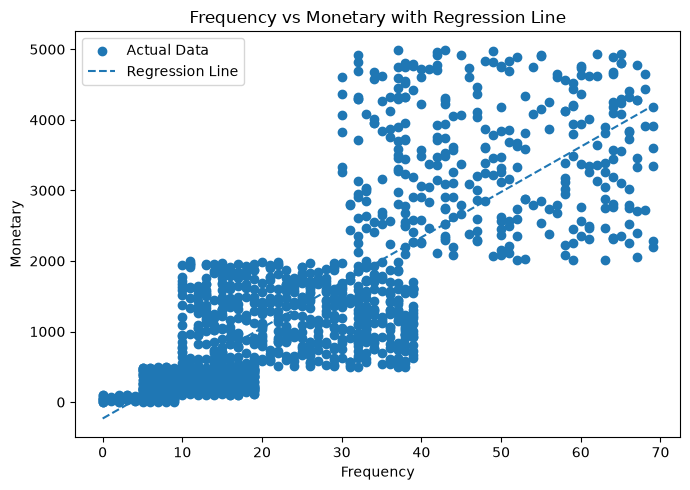

In [58]:
line_model = LinearRegression()

line_model.fit(
    X_train[["Frequency"]],
    y_train
)

frequency_values = np.linspace(
    X_test["Frequency"].min(),
    X_test["Frequency"].max(),
    100
)

monetary_values = line_model.predict(
    frequency_values.reshape(-1, 1)
)

plt.figure(figsize=(7, 5))

plt.scatter(
    X_test["Frequency"],
    y_test,
    label="Actual Data"
)

plt.plot(
    frequency_values,
    monetary_values,
    linestyle="--",
    label="Regression Line"
)

plt.xlabel("Frequency")
plt.ylabel("Monetary")
plt.title("Frequency vs Monetary with Regression Line")

plt.legend()
plt.tight_layout()
plt.show()

<h2>9.Hyperparamter Tuning.</h2>

In [59]:
model_details = {
    "Ridge Regression": (
        Ridge(),
        {
            "model__alpha": [0.01, 0.1, 1, 10, 100]
        }
    ),

    "Lasso Regression": (
        Lasso(),
        {
            "model__alpha": [0.001, 0.01, 0.1, 1]
        }
    ),

    "ElasticNet Regression": (
        ElasticNet(),
        {
            "model__alpha": [0.01, 0.1, 1],
            "model__l1_ratio": [0.2, 0.5, 0.8]
        }
    ),

    "Decision Tree Regressor": (
        DecisionTreeRegressor(random_state=42),
        {
            "model__max_depth": [3, 5, 10, 15, None],
            "model__min_samples_split": [2, 5, 10]
        }
    ),

    "Random Forest Regressor": (
        RandomForestRegressor(random_state=42),
        {
            "model__n_estimators": [50, 100, 150],
            "model__max_depth": [None, 10, 20]
        }
    ),

    "Gradient Boosting Regressor": (
        GradientBoostingRegressor(random_state=42),
        {
            "model__n_estimators": [50, 100, 150],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [2, 3, 5]
        }
    ),

    "Support Vector Regressor": (
        SVR(),
        {
            "model__C": [1, 10, 100],
            "model__kernel": ["linear", "rbf"]
        }
    ),

    "KNN Regressor": (
        KNeighborsRegressor(),
        {
            "model__n_neighbors": [3, 5, 7, 9]
        }
    )
}

In [60]:
tuned_results = []

for model_name in top_models:

    model, parameters = model_details[model_name]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    grid = GridSearchCV(
        pipeline,
        parameters,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    tuned_pred = grid.predict(X_test)

    tuned_r2 = r2_score(y_test, tuned_pred)
    tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
    tuned_mae = mean_absolute_error(y_test, tuned_pred)

    original_r2 = results_df[
        results_df["Model"] == model_name
    ]["R2"].values[0]

    improvement = tuned_r2 - original_r2

    tuned_results.append([
        model_name,
        original_r2,
        tuned_r2,
        tuned_rmse,
        tuned_mae,
        improvement,
        grid.best_params_
    ])

    print("\nModel:", model_name)
    print("Best Parameters:", grid.best_params_)
    print("Original R2:", original_r2)
    print("Tuned R2:", tuned_r2)
    print("Improvement:", improvement)


Model: Random Forest Regressor
Best Parameters: {'model__max_depth': 10, 'model__n_estimators': 100}
Original R2: 0.8469156129388548
Tuned R2: 0.8483579341071867
Improvement: 0.0014423211683319836

Model: Gradient Boosting Regressor
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 100}
Original R2: 0.8443517191499212
Tuned R2: 0.8471299379433483
Improvement: 0.0027782187934271008


In [65]:
tuned_results_df = pd.DataFrame(
    tuned_results,
    columns=[
        "Model",
        "Original R2",
        "Tuned R2",
        "Tuned RMSE",
        "Tuned MAE",
        "R2 Improvement",
        "Best Parameters"
    ]
)

tuned_results_df

,Model,Original R2,Tuned R2,Tuned RMSE,Tuned MAE,R2 Improvement,Best Parameters
0,Random Forest Regressor,0.846916,0.848358,505.446509,349.814595,0.001442,"{'model__max_depth': 10, 'model__n_estimators'..."
1,Gradient Boosting Regressor,0.844352,0.847130,507.488933,353.448209,0.002778,"{'model__learning_rate': 0.05, 'model__max_dep..."


<h2>10.Best Model Selection and Predictions</h2>

In [66]:
prediction_dict = {
    "Linear Regression": linear_pred,
    "Ridge Regression": ridge_pred,
    "Lasso Regression": lasso_pred,
    "ElasticNet Regression": elastic_pred,
    "Polynomial Regression": poly_pred,
    "Decision Tree Regressor": tree_pred,
    "Random Forest Regressor": forest_pred,
    "Gradient Boosting Regressor": gradient_pred,
    "Support Vector Regressor": svr_pred,
    "KNN Regressor": knn_pred
}

In [67]:
best_model_name = results_df.iloc[0]["Model"]

print("Best Model:", best_model_name)

Best Model: Random Forest Regressor


In [68]:
best_pred = prediction_dict[best_model_name]
print(best_pred)
print("Best predictions obtained successfully")

[ 299.16  308.02 1145.02 ...  296.18   50.63 3683.23]
Best predictions obtained successfully


<h2>11.Regression Model Visualisation</h2>

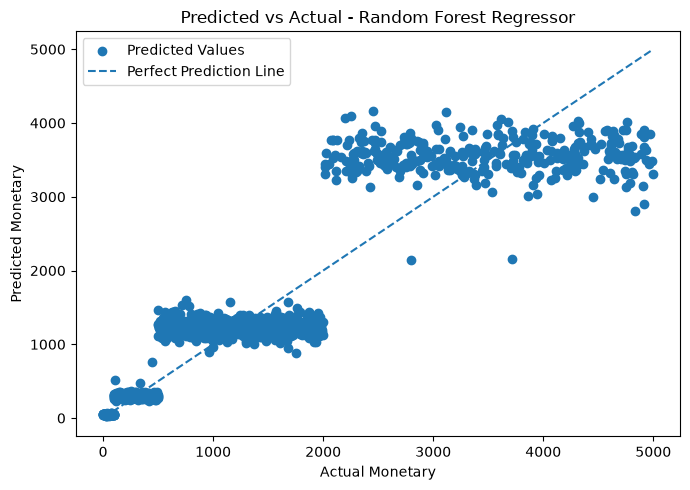

In [69]:
plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    best_pred,
    label="Predicted Values"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    label="Perfect Prediction Line"
)

plt.xlabel("Actual Monetary")
plt.ylabel("Predicted Monetary")

plt.title(
    "Predicted vs Actual - " + best_model_name
)

plt.legend()

plt.tight_layout()
plt.show()

The predicted values are compared with the actual Monetary values. A good regression model should have the points close to a straight diagonal pattern, indicating that predicted spending values are close to the actual values.

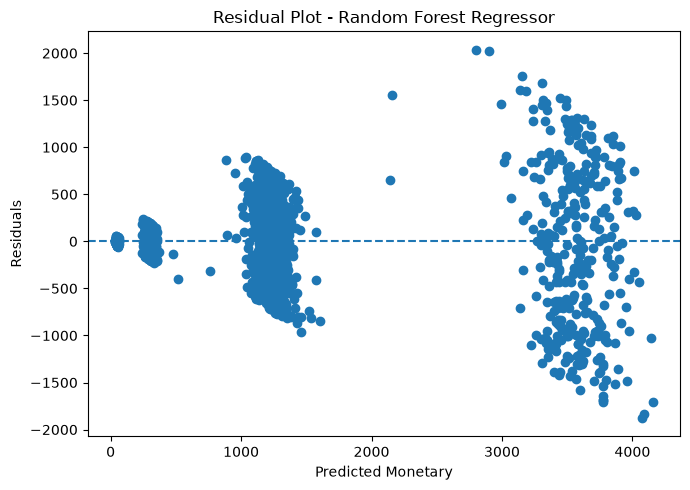

In [70]:
residuals = y_test - best_pred

plt.figure(figsize=(7, 5))

plt.scatter(best_pred, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Monetary")
plt.ylabel("Residuals")
plt.title("Residual Plot - " + best_model_name)

plt.tight_layout()
plt.show()

The residual plot shows the prediction errors of the model. Residuals distributed around zero indicate that the model is making errors in both positive and negative directions without a strong systematic pattern.

Feature Importance

In [71]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
3,Session_Count,0.604569
1,Frequency,0.117585
2,Avg_Order_Value,0.111076
8,Wishlist_Adds,0.044537
11,Engagement_Score,0.032909
0,Recency,0.018394
4,Avg_Session_Duration,0.018267
9,Cart_Abandon_Rate,0.017165
5,Pages_Viewed,0.013932
6,Clicks,0.010896


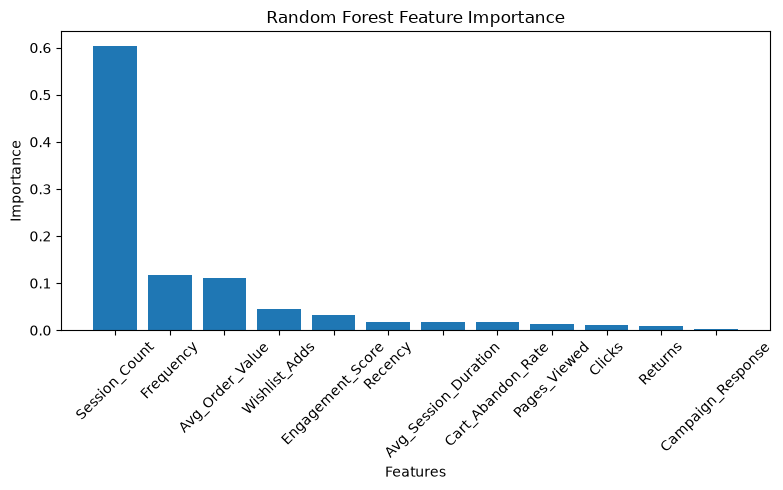

In [72]:
plt.figure(figsize=(8, 5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The feature importance plot shows which customer behavior features contribute most to predicting Monetary. Features with higher importance have a stronger influence on the Random Forest regression model.

<h2>12.Cross Validation of Selected Models</h2>

In [73]:
cv_results = []

for model_name in top_models:

    model, parameters = model_details[model_name]

    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    cv_results.append([
        model_name,
        scores.mean(),
        scores.std()
    ])

    print("\nModel:", model_name)
    print("5-Fold R2 Scores:", scores)
    print("Mean R2:", scores.mean())
    print("Standard Deviation:", scores.std())


Model: Random Forest Regressor
5-Fold R2 Scores: [0.84387044 0.85720823 0.84345938 0.85873555 0.85601131]
Mean R2: 0.8518569823285773
Standard Deviation: 0.0067455685968902755

Model: Gradient Boosting Regressor
5-Fold R2 Scores: [0.83681976 0.85227834 0.83102804 0.84853011 0.84818508]
Mean R2: 0.8433682685548982
Standard Deviation: 0.008054811843842791


<h2>12.1 Five Fold Cross Validation</h2>

In [74]:
cv_results_df = pd.DataFrame(
    cv_results,
    columns=[
        "Model",
        "Mean CV R2",
        "CV R2 Standard Deviation"
    ]
)

display(cv_results_df)

,Model,Mean CV R2,CV R2 Standard Deviation
0,Random Forest Regressor,0.851857,0.006746
1,Gradient Boosting Regressor,0.843368,0.008055
